In [1]:
import pandas as pd
import cvxpy as cp
import numpy as np
from numpy.linalg import pinv
from scipy.sparse import lil_matrix
from scipy.stats import binom
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import log_loss
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
import tqdm

In [2]:
# Testing
n, N = 500, 20  # sample size and image side length
p = N * N
X = np.random.randn(n, p)
beta_true = np.zeros((N, N))
beta_true[5:15, 5:15] = 1.0  # block pattern
y_prob = 1 / (1 + np.exp(-X @ beta_true.ravel()))
y = np.random.binomial(1, y_prob)

# CVXPY Variable
beta = cp.Variable((N, N))

# Logistic loss
Xbeta = X @ cp.vec(beta)
log_likelihood = cp.sum(cp.multiply(y, Xbeta) - cp.logistic(Xbeta))  # log(p) = y log μ + (1−y) log(1−μ)

# Total Variation penalty (anisotropic)
tv_penalty = cp.tv(beta)  # uses anisotropic TV: sum of |∇_x| + |∇_y|

# Regularized objective
lambda_tv = 2.5  # adjust this as needed
objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)

# Problem and solve
prob = cp.Problem(objective)
prob.solve(verbose=True)

# Result
beta_hat = beta.value

C:\Users\Jonathan\anaconda3\Lib\site-packages\cvxpy\atoms\affine\vec.py:40: FutureWarning: 
    You didn't specify the order of the vec expression. The default order
    used in CVXPY is Fortran ('F') order. This default will change to match NumPy's
    default order ('C') in a future version of CVXPY.
    To suppress this warning, please specify the order explicitly.
    
  warnings.warn(vec_order_warning, FutureWarning)
(CVXPY) Jul 24 03:12:53 PM: Your problem has 400 variables, 0 constraints, and 0 parameters.
(CVXPY) Jul 24 03:12:53 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 24 03:12:53 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 24 03:12:53 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 24 03:12:53 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 24 03:12:53 PM: Compiling problem

                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 2261
  constraint

(CVXPY) Jul 24 03:12:54 PM: Problem status: optimal
(CVXPY) Jul 24 03:12:54 PM: Optimal value: -1.115e+02
(CVXPY) Jul 24 03:12:54 PM: Compilation took 8.715e-02 seconds
(CVXPY) Jul 24 03:12:54 PM: Solver (including time spent in interface) took 7.299e-01 seconds


 18  +1.1151e+02  +1.1151e+02  1.80e-08  5.90e-10  3.18e-09  3.01e-09  1.29e-09  7.92e-01  
 19  +1.1151e+02  +1.1151e+02  7.13e-09  2.35e-10  1.26e-09  1.20e-09  5.09e-10  6.34e-01  
---------------------------------------------------------------------------------------------
Terminated with status = Solved
solve time = 692.5447ms
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


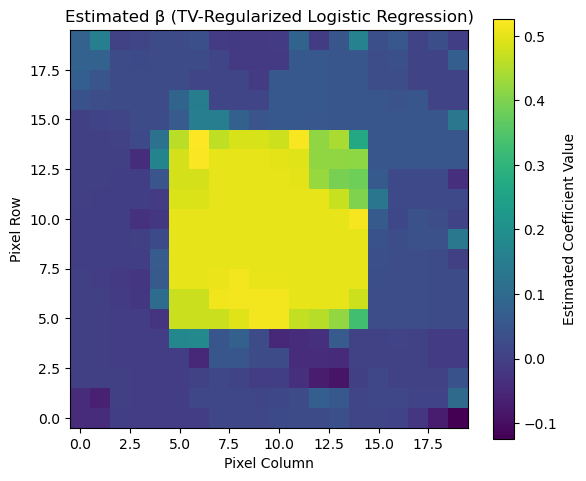

In [3]:
# Assuming beta_hat is available from previous context
# For demonstration, let's create a mock result (you can replace this with your actual result)
N = 20

# Plot the estimated beta image
plt.figure(figsize=(6, 5))
plt.imshow(beta_hat, cmap='viridis', origin='lower')
plt.colorbar(label='Estimated Coefficient Value')
plt.title('Estimated β (TV-Regularized Logistic Regression)')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.tight_layout()
plt.show()

In [4]:
# Bootstrapping
# Sample (1000?) from the possesion dataframe. From those samples, sample the movement data from that (x,y,z)
# Apply to model

## Applying Logistic Regression with TV

Now that we have dataframes with the necessary information to construct our `X` matrix and `y` vector using `x_bins`, `y_bins` and `scored`. Once constructed, we can define our $\hat{\beta}$ using a GLM consisiting of: 

$
\
\hat{\beta} = \min_{\mu \in \mathbb{R}^p} -\log \mathcal{L}(g^{-1}(X\mu); \mathbf{y}) + \lambda \sum_{l=1}^{p} \sum_{l' \in \partial l} |\mu_l - \mu_{l'}|
\
$

Where $\hat{\beta}$ is the image we are producing to show distinct areas of the court where the "threat" to score for The Raptors is highest. The parameter $\lambda$ determines the strength of our TV loss, which will be adjusted to produce optimal results. The first iteration of this method will be done on the original data with 103 possesions. Further iterations will be done with bootstrapping and sampling without replacement to simulate larger sets of data and to potentially produce confidence intervals and other comparison metrics.

(CVXPY) Jul 24 03:12:54 PM: Your problem has 200 variables, 400 constraints, and 0 parameters.
(CVXPY) Jul 24 03:12:54 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 24 03:12:54 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 24 03:12:54 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 24 03:12:54 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 24 03:12:55 PM: Compiling problem (target solver=ECOS).
(CVXPY) Jul 24 03:12:55 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Jul 24 03:12:55 PM: Applying reduction FlipObjective
(CVXPY) Jul 24 03:12:55 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 24 03:12:55 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 24 03:12:55 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jul 24 03:12:55 PM: Applying reduction ECOS
(CVXPY) Jul 24 03:12:55 PM: Finished problem compilation (took 5.386e-01 seconds).
(CVXPY) Jul 24 03:12:55 PM: Invoking solver ECOS  to obtain a solution.
(CVXPY) Jul 24 03:12:55 PM: Problem status: optimal
(CVXPY) Jul 24 03:12:55 PM: Optimal value: -6.320e-01
(CVXPY) Jul 24 03:12:55 PM: Compilation took 5.386e-01 seconds
(CVXPY) Jul 24 03:12:55 PM: Solver (including time spent in interface) took 5.767e-02 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


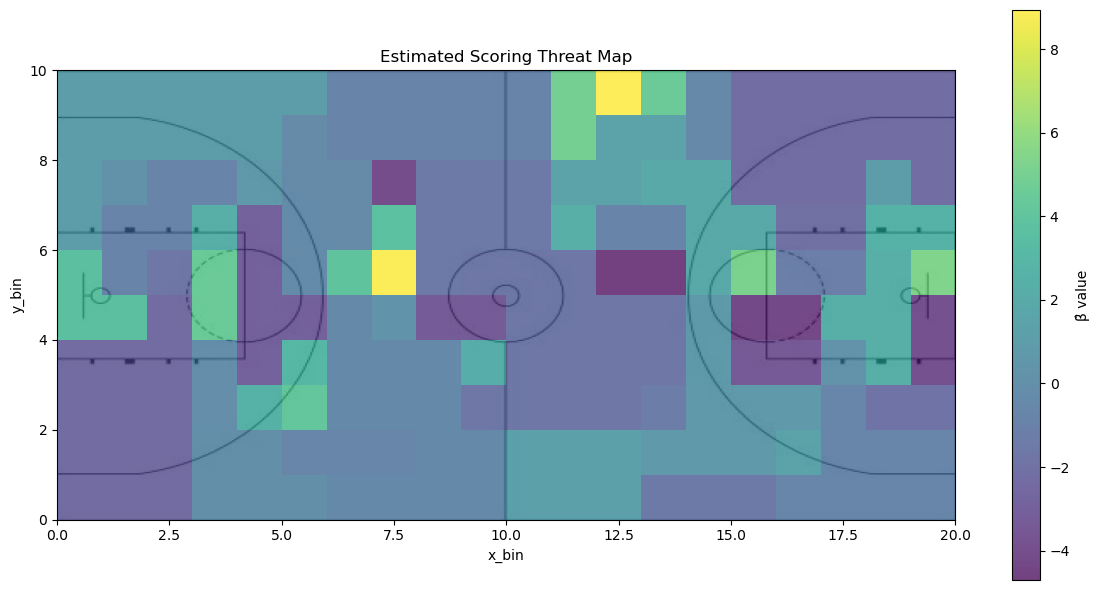

In [6]:
# Load your CSV file
df = pd.read_csv("Data/analysis_ready.csv")

# Parameters
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Step 1: Map each (x_bin, y_bin) to index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Step 2: Prepare possession-level feature matrix X and outcome vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)
possession_to_index = {p: i for i, p in enumerate(possessions)}

for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1
    y[i] = group['scored'].iloc[0]  # assumes consistency per possession

#X = normalize(X, norm='l1', axis=1)

# Step 3: Define TV-regularized logistic regression (TV disabled for now)
beta_grid = cp.Variable((grid_width, grid_height))

# Flatten beta for dot product with X
beta_flat = cp.vec(beta_grid, order="C")
logits = X @ beta_flat
log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

# Define objective (λ = 0 for now; TV can be added later)
tv_terms = []
for x in range(grid_width):
    for y in range(grid_height):
        if x + 1 < grid_width:
            tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x + 1, y]))
        if y + 1 < grid_height:
            tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x, y + 1]))

constraints = [beta_grid >= -10, beta_grid <= 10]
tv_penalty = cp.sum(tv_terms)
lambda_tv = .001 # adjust as needed
objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
problem = cp.Problem(objective, constraints)

# Solve with fallback
try:
    result = problem.solve(solver=cp.ECOS,verbose=True)
except:
    print("ECOS failed, trying SCS...")
    result = problem.solve(solver=cp.SCS, verbose=False)

# Check result
if beta_grid.value is None:
    raise RuntimeError("Optimization failed. Try simplifying the problem or inspecting the data.")
else:
    beta_est = beta_grid.value

# Step 4: Visualize
court_img = mpimg.imread("court.jpg")

# Plot overlay
fig, ax = plt.subplots(figsize=(12, 6))

# Display the court image
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')

# Overlay heatmap (transposed to match orientation)
heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height],
                    cmap="viridis", alpha=0.75)

# Labels and formatting
ax.set_title("Estimated Scoring Threat Map")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.colorbar(heatmap, ax=ax, label="β̂ value")
plt.tight_layout()
plt.show()


In [7]:
df["possession_number"].nunique()

102

## First Iteration - Original Dataframe

This appears to be working as intended. We can see some distinct areas that have a higher threat to score using the limited amount of data available to us. To improve the model's performance, we will test for optimal $\lambda$ values by plotting log-loss and and smoothness against $\lambda$. This is completed below using k-fold cross validation where $k = 5$.

100%|██████████| 10/10 [00:37<00:00,  3.76s/it]


Best λ = 4.6416


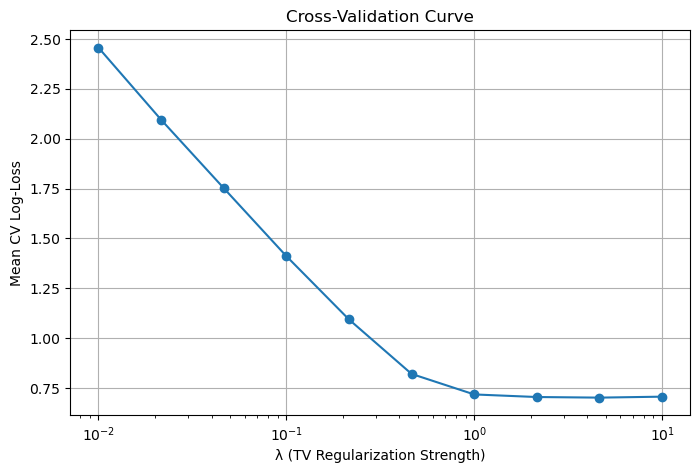

In [9]:
# Range of λ values to test
lambda_values = np.logspace(-2, 1, 10)  # from 0.01 to 10 (adjust as needed)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)

# Store mean validation loss per lambda
lambda_log_losses = []

for lambda_tv in tqdm.tqdm(lambda_values):
    fold_losses = []

    for train_idx, val_idx in kfold.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        # Redefine variable and problem per fold
        beta_grid = cp.Variable((grid_width, grid_height))
        beta_flat = cp.vec(beta_grid, order="C")
        logits = X_train @ beta_flat
        log_likelihood = cp.sum(cp.multiply(y_train, logits) - cp.logistic(logits))

        # TV penalty
        tv_terms = []
        for x in range(grid_width):
            for y_ in range(grid_height):
                if x + 1 < grid_width:
                    tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x + 1, y_]))
                if y_ + 1 < grid_height:
                    tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x, y_ + 1]))
        tv_penalty = cp.sum(tv_terms)

        constraints = [beta_grid >= -10, beta_grid <= 10]
        objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(solver=cp.ECOS,verbose=False)
            beta_est = beta_grid.value
        except:
            fold_losses.append(np.inf)
            continue

        # Evaluate log-loss on validation set
        if beta_est is not None:
            preds = 1 / (1 + np.exp(-(X_val @ beta_est.ravel())))
            fold_losses.append(log_loss(y_val, preds))
        else:
            fold_losses.append(np.inf)

    # Average fold loss for this λ
    lambda_log_losses.append(np.mean(fold_losses))

# Select best λ
best_lambda = lambda_values[np.argmin(lambda_log_losses)]
print(f"Best λ = {best_lambda:.4f}")

plt.figure(figsize=(8, 5))
plt.semilogx(lambda_values, lambda_log_losses, marker='o')
plt.xlabel("λ (TV Regularization Strength)")
plt.ylabel("Mean CV Log-Loss")
plt.title("Cross-Validation Curve")
plt.grid(True)
plt.show()

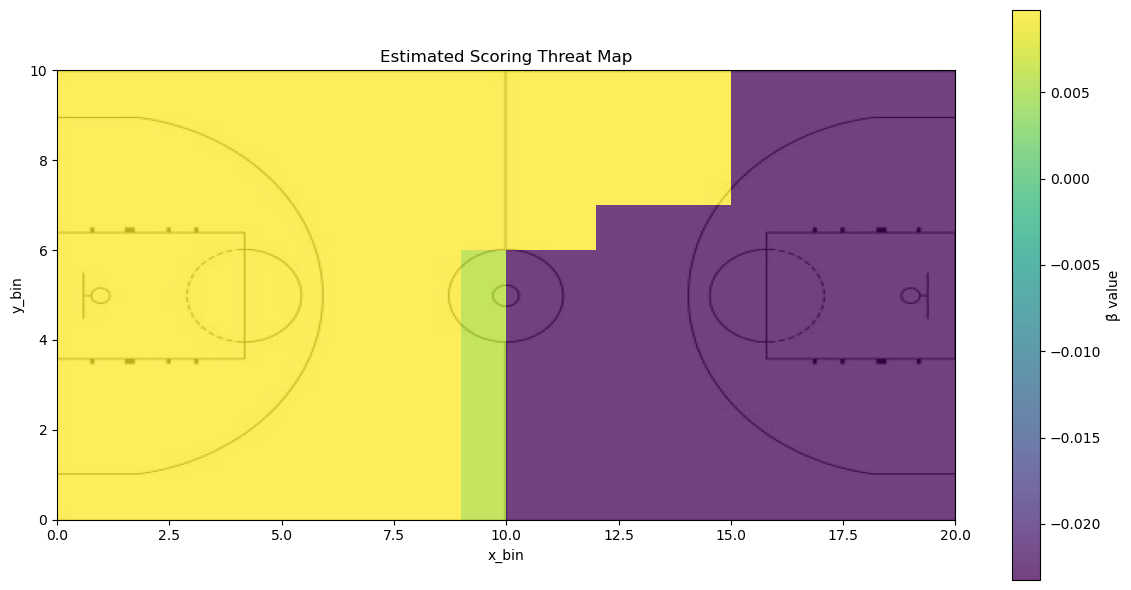

In [10]:
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Step 1: Map each (x_bin, y_bin) to index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Step 2: Prepare possession-level feature matrix X and outcome vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)
possession_to_index = {p: i for i, p in enumerate(possessions)}

for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1
    y[i] = group['scored'].iloc[0]  # assumes consistency per possession

#X = normalize(X, norm='l1', axis=1)

# Step 3: Define TV-regularized logistic regression (TV disabled for now)
beta_grid = cp.Variable((grid_width, grid_height))

# Flatten beta for dot product with X
beta_flat = cp.vec(beta_grid, order="C")
logits = X @ beta_flat
log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

# Define objective (λ = 0 for now; TV can be added later)
tv_terms = []
for x in range(grid_width):
    for y in range(grid_height):
        if x + 1 < grid_width:
            tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x + 1, y]))
        if y + 1 < grid_height:
            tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x, y + 1]))

constraints = [beta_grid >= -10, beta_grid <= 10]
tv_penalty = cp.sum(tv_terms)
lambda_tv = 4.6416 # optimal lambda from CV
objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
problem = cp.Problem(objective, constraints)

# Solve with fallback
try:
    result = problem.solve(solver=cp.ECOS,verbose=False)
except:
    print("ECOS failed, trying SCS...")
    result = problem.solve(solver=cp.SCS, verbose=False)

# Check result
if beta_grid.value is None:
    raise RuntimeError("Optimization failed. Try simplifying the problem or inspecting the data.")
else:
    beta_est = beta_grid.value

# Step 4: Visualize
court_img = mpimg.imread("court.jpg")

# Plot overlay
fig, ax = plt.subplots(figsize=(12, 6))

# Display the court image
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')

# Overlay heatmap (transposed to match orientation)
heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height],
                    cmap="viridis", alpha=0.75)

# Labels and formatting
ax.set_title("Estimated Scoring Threat Map")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.colorbar(heatmap, ax=ax, label="β̂ value")
plt.tight_layout()
plt.show()

## Results

With such a large lambda, the model is prioritizing smoothness over sparsity and is not able to properly distinguish sectors of high threat. This could be due to a relatively small amount of possessions and our null hypothesis: that there are no distinct areas of high threat. Before rejecting any of our hypotheses, we will handle a lack of data with bootstrapping.

## Bootstrapping

The method is simple. To increase the amount of possessions we have, we will randomly select 1000 possessions from our current pool of 103 with replacement. From the randomly selected possessions, we will randomly select 100 movement measurements with replacement. This will provide us with a new dataframe that contains 100 "moments" from 1000 possessions, so we will have dataframe with 100000 entries.

In [12]:
# Bootstrapping

df = pd.read_csv("Data/analysis_ready.csv")  # Adjust the path as needed

# Group original data by possession
grouped = list(df.groupby("possession_number"))

# Filter to only include possessions with more than 100 samples
grouped = [(pid, group) for pid, group in grouped if len(group) > 100]

# Check how many qualifying possessions remain
original_possessions = len(grouped)

# Parameters for bootstrapping
n_simulated_possessions = 1000
samples_per_possession = 100
new_rows = []

# Create a random number generator
rng = np.random.default_rng(seed=42)

# Generate new possession IDs
new_possession_ids = range(100000, 100000 + n_simulated_possessions)

# Bootstrapping loop
for new_pid in new_possession_ids:
    # Randomly select one of the qualifying possessions
    _, real_group = grouped[rng.integers(0, original_possessions)]
    
    # Sample 100 rows (with replacement) from that possession
    sampled_rows = real_group.sample(
        n=samples_per_possession,
        replace=True,
        random_state=rng.integers(1e6)
    ).copy()

    # Assign new possession number
    sampled_rows["possession_number"] = new_pid

    # Append to new dataset
    new_rows.append(sampled_rows)

# Combine all rows into a new DataFrame
df_bootstrap = pd.concat(new_rows, ignore_index=True)

# Save to CSV
df_bootstrap.to_csv("Data/bootstrapped_analysis_ready.csv", index=False)

## Modelling on the Bootstrapped Data

*Insert text here*

(CVXPY) Jul 24 03:13:37 PM: Your problem has 200 variables, 400 constraints, and 0 parameters.
(CVXPY) Jul 24 03:13:37 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 24 03:13:37 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 24 03:13:37 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 24 03:13:37 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 24 03:13:37 PM: Compiling problem (target solver=ECOS).
(CVXPY) Jul 24 03:13:37 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Jul 24 03:13:37 PM: Applying reduction FlipObjective
(CVXPY) Jul 24 03:13:37 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 24 03:13:37 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 24 03:13:37 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jul 24 03:13:38 PM: Applying reduction ECOS
(CVXPY) Jul 24 03:13:38 PM: Finished problem compilation (took 6.698e-01 seconds).
(CVXPY) Jul 24 03:13:38 PM: Invoking solver ECOS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Jul 24 03:13:38 PM: Problem status: optimal
(CVXPY) Jul 24 03:13:38 PM: Optimal value: -1.652e+00
(CVXPY) Jul 24 03:13:38 PM: Compilation took 6.698e-01 seconds
(CVXPY) Jul 24 03:13:38 PM: Solver (including time spent in interface) took 2.596e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


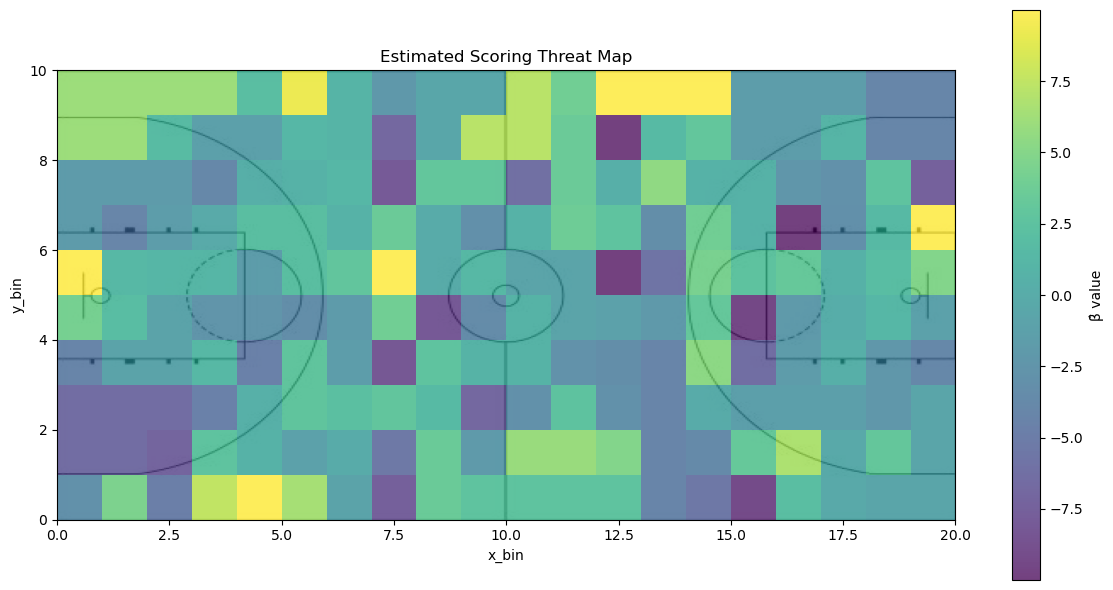

In [14]:
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Step 1: Map each (x_bin, y_bin) to index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Step 2: Prepare possession-level feature matrix X and outcome vector y
possessions = df_bootstrap['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df_bootstrap.groupby('possession_number')], dtype=np.int8)
possession_to_index = {p: i for i, p in enumerate(possessions)}

for pid, group in df_bootstrap.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1
    y[i] = group['scored'].iloc[0]  # assumes consistency per possession

#X = normalize(X, norm='l1', axis=1)

# Step 3: Define TV-regularized logistic regression (TV disabled for now)
beta_grid = cp.Variable((grid_width, grid_height))

# Bound beta to prevent numerical instability
constraints = [beta_grid >= -10, beta_grid <= 10]

# Flatten beta for dot product with X
beta_flat = cp.vec(beta_grid, order="C")
logits = X @ beta_flat
log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

# Define objective (λ = 0 for now; TV can be added later)
tv_terms = []
for x in range(grid_width):
    for y in range(grid_height):
        if x + 1 < grid_width:
            tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x + 1, y]))
        if y + 1 < grid_height:
            tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x, y + 1]))
tv_penalty = cp.sum(tv_terms)
lambda_tv = .001 # adjust as needed
objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
problem = cp.Problem(objective, constraints)

# Solve with fallback
try:
    result = problem.solve(solver=cp.ECOS,verbose=True)
except:
    print("ECOS failed, trying SCS...")
    result = problem.solve(solver=cp.SCS, verbose=True)

# Check result
if beta_grid.value is None:
    raise RuntimeError("Optimization failed. Try simplifying the problem or inspecting the data.")
else:
    beta_est = beta_grid.value

# Step 4: Visualize
court_img = mpimg.imread("court.jpg")

# Plot overlay
fig, ax = plt.subplots(figsize=(12, 6))

# Display the court image
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')

# Overlay heatmap (transposed to match orientation)
heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height],
                    cmap="viridis", alpha=0.75)

# Labels and formatting
ax.set_title("Estimated Scoring Threat Map")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.colorbar(heatmap, ax=ax, label="β̂ value")
plt.tight_layout()
plt.show()

## CV on Bootstrapped Data

Data leakage? Search other methods. <br>
Bidirectional offence. <br>
GroupFold?

100%|██████████| 15/15 [01:05<00:00,  4.38s/it]


Best λ = 0.0611


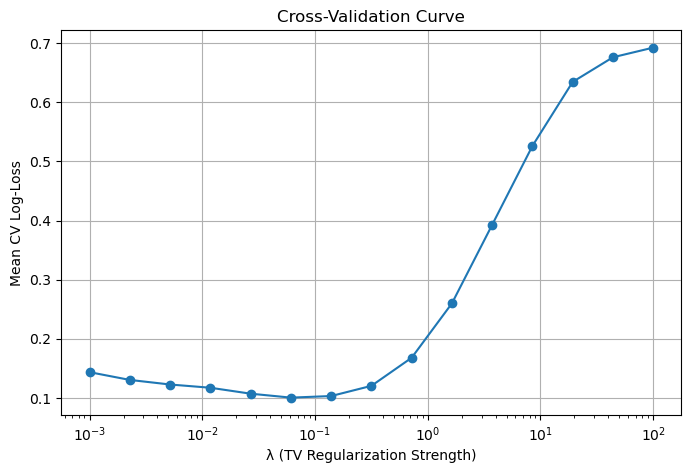

In [16]:
lambda_values = np.logspace(-3, 2, 15)  #(adjust as needed)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
y = np.array([group['scored'].iloc[0] for _, group in df_bootstrap.groupby('possession_number')], dtype=np.int8)

# Store mean validation loss per lambda
lambda_log_losses = []

for lambda_tv in tqdm.tqdm(lambda_values):
    fold_losses = []

    for train_idx, val_idx in kfold.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        # Redefine variable and problem per fold
        beta_grid = cp.Variable((grid_width, grid_height))
        beta_flat = cp.vec(beta_grid, order="C")
        logits = X_train @ beta_flat
        log_likelihood = cp.sum(cp.multiply(y_train, logits) - cp.logistic(logits))

        # TV penalty
        tv_terms = []
        for x in range(grid_width):
            for y_ in range(grid_height):
                if x + 1 < grid_width:
                    tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x + 1, y_]))
                if y_ + 1 < grid_height:
                    tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x, y_ + 1]))
        tv_penalty = cp.sum(tv_terms)

        constraints = [beta_grid >= -10, beta_grid <= 10]
        objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(solver=cp.ECOS,verbose=False)
            beta_est = beta_grid.value
        except:
            fold_losses.append(np.inf)
            continue

        # Evaluate log-loss on validation set
        if beta_est is not None:
            preds = 1 / (1 + np.exp(-(X_val @ beta_est.ravel())))
            fold_losses.append(log_loss(y_val, preds))
        else:
            fold_losses.append(np.inf)

    # Average fold loss for this λ
    lambda_log_losses.append(np.mean(fold_losses))

# Select best λ
best_lambda = lambda_values[np.argmin(lambda_log_losses)]
print(f"Best λ = {best_lambda:.4f}")

plt.figure(figsize=(8, 5))
plt.semilogx(lambda_values, lambda_log_losses, marker='o')
plt.xlabel("λ (TV Regularization Strength)")
plt.ylabel("Mean CV Log-Loss")
plt.title("Cross-Validation Curve")
plt.grid(True)
plt.show()

  0%|          | 0/7 [00:00<?, ?it/s]C:\Users\Jonathan\anaconda3\Lib\site-packages\cvxpy\problems\problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
100%|██████████| 7/7 [00:31<00:00,  4.52s/it]


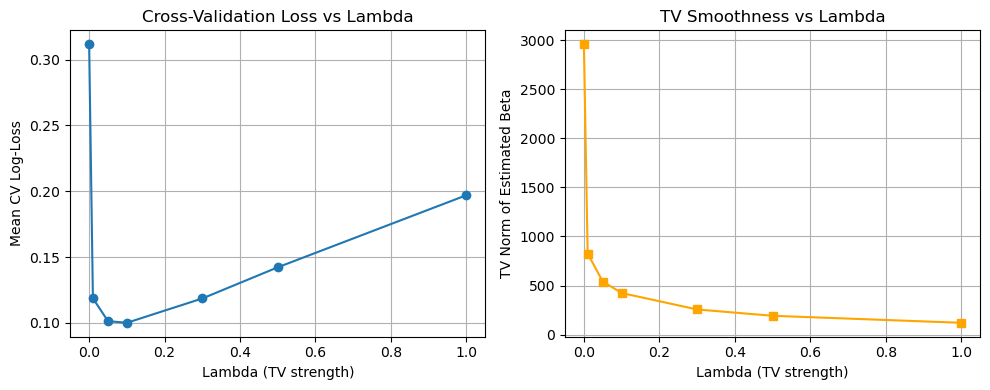

In [17]:
# Load the bootstrapped data
file_path = "Data/bootstrapped_analysis_ready.csv"
df = pd.read_csv(file_path)

# Grid configuration
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Map (x_bin, y_bin) to flat index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Prepare design matrix X and outcome vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)

possession_to_index = {p: i for i, p in enumerate(possessions)}
for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1

# Normalize each row of X to reduce bias from long possessions
#X = normalize(X, norm='l1', axis=1)

# Lambda values to try
lambda_values = np.array([0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0])
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

lambda_log_losses = []
lambda_tv_magnitudes = []
beta_maps = []

for lambda_tv in tqdm.tqdm(lambda_values):
    fold_losses = []
    fold_tv_norms = []

    for train_idx, val_idx in kfold.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        beta_grid = cp.Variable((grid_width, grid_height))
        beta_flat = cp.vec(beta_grid, order="C")
        logits = X_train @ beta_flat
        log_likelihood = cp.sum(cp.multiply(y_train, logits) - cp.logistic(logits))

        # Total variation penalty
        tv_terms = []
        for x in range(grid_width):
            for y_idx in range(grid_height):
                if x + 1 < grid_width:
                    tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x + 1, y_idx]))
                if y_idx + 1 < grid_height:
                    tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x, y_idx + 1]))
        tv_penalty = cp.sum(tv_terms)

        constraints = [beta_grid >= -10, beta_grid <= 10]
        objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(solver=cp.ECOS,verbose=False)
            beta_est = beta_grid.value
        except:
            fold_losses.append(np.inf)
            fold_tv_norms.append(np.inf)
            continue

        if beta_est is not None:
            preds = 1 / (1 + np.exp(-(X_val @ beta_est.ravel(order="C"))))
            fold_losses.append(log_loss(y_val, preds))
            # Record TV norm
            tv_value = sum(
                np.abs(beta_est[x, y] - beta_est[x+1, y])
                for x in range(grid_width-1)
                for y in range(grid_height)
            ) + sum(
                np.abs(beta_est[x, y] - beta_est[x, y+1])
                for x in range(grid_width)
                for y in range(grid_height-1)
            )
            fold_tv_norms.append(tv_value)
        else:
            fold_losses.append(np.inf)
            fold_tv_norms.append(np.inf)

    lambda_log_losses.append(np.mean(fold_losses))
    lambda_tv_magnitudes.append(np.mean(fold_tv_norms))
    beta_maps.append(beta_est)

# Plot CV log-loss vs lambda
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(lambda_values, lambda_log_losses, marker='o')
plt.xlabel("Lambda (TV strength)")
plt.ylabel("Mean CV Log-Loss")
plt.title("Cross-Validation Loss vs Lambda")
plt.grid(True)

# Plot TV norm vs lambda
plt.subplot(1, 2, 2)
plt.plot(lambda_values, lambda_tv_magnitudes, marker='s', color='orange')
plt.xlabel("Lambda (TV strength)")
plt.ylabel("TV Norm of Estimated Beta")
plt.title("TV Smoothness vs Lambda")
plt.grid(True)
plt.tight_layout()
plt.show()

### Using Optimal Lambda from CV

Bidirectional still.

(CVXPY) Jul 24 03:15:18 PM: Your problem has 200 variables, 400 constraints, and 0 parameters.
(CVXPY) Jul 24 03:15:18 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 24 03:15:18 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 24 03:15:18 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 24 03:15:18 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 24 03:15:18 PM: Compiling problem (target solver=ECOS).
(CVXPY) Jul 24 03:15:18 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Jul 24 03:15:18 PM: Applying reduction FlipObjective
(CVXPY) Jul 24 03:15:18 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 24 03:15:18 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 24 03:15:18 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jul 24 03:15:18 PM: Applying reduction ECOS
(CVXPY) Jul 24 03:15:19 PM: Finished problem compilation (took 6.938e-01 seconds).
(CVXPY) Jul 24 03:15:19 PM: Invoking solver ECOS  to obtain a solution.
(CVXPY) Jul 24 03:15:19 PM: Problem status: optimal
(CVXPY) Jul 24 03:15:19 PM: Optimal value: -4.679e+01


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


(CVXPY) Jul 24 03:15:19 PM: Compilation took 6.938e-01 seconds
(CVXPY) Jul 24 03:15:19 PM: Solver (including time spent in interface) took 1.782e-01 seconds


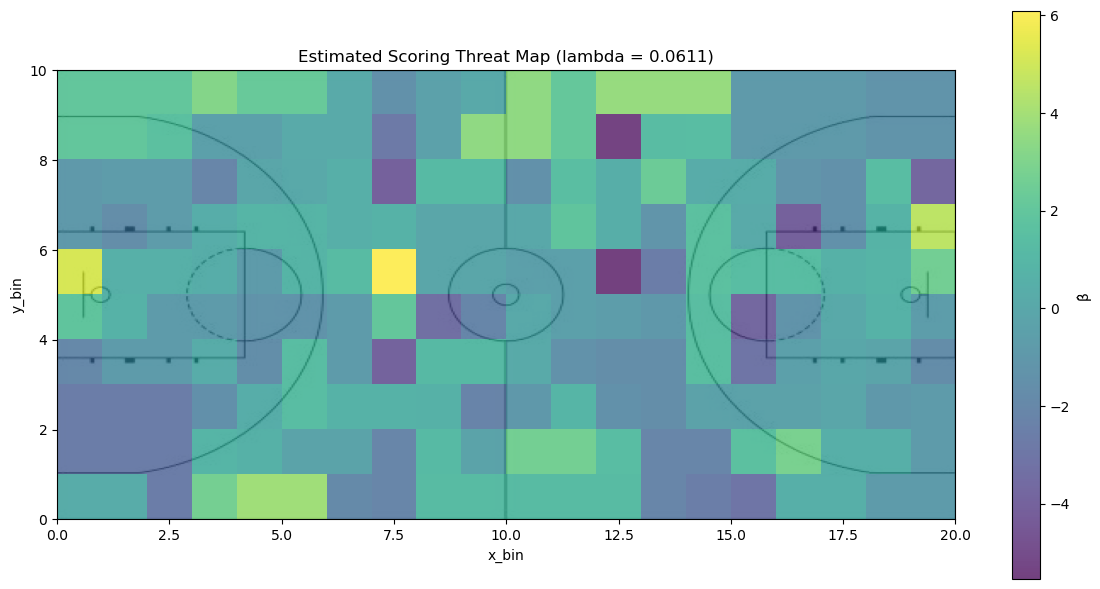

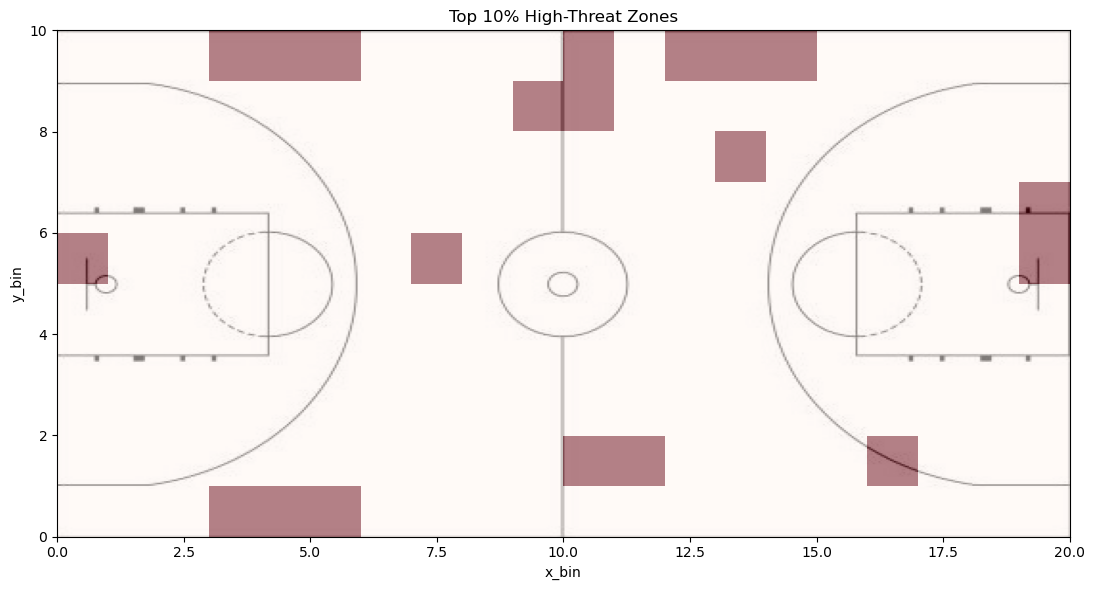

In [19]:
# Load bootstrapped data
file_path = "Data/bootstrapped_analysis_ready.csv"
df = pd.read_csv(file_path)

# Grid configuration
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Construct design matrix X and label vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)

possession_to_index = {p: i for i, p in enumerate(possessions)}
for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1

# Fit final model with lambda = anything (lower seems to be better)
lambda_tv = 0.0611
beta_grid = cp.Variable((grid_width, grid_height))
beta_flat = cp.vec(beta_grid, order="C")
logits = X @ beta_flat
log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

# TV penalty
tv_terms = []
for x in range(grid_width):
    for y_idx in range(grid_height):
        if x + 1 < grid_width:
            tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x + 1, y_idx]))
        if y_idx + 1 < grid_height:
            tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x, y_idx + 1]))
tv_penalty = cp.sum(tv_terms)

constraints = [beta_grid >= -10, beta_grid <= 10]
objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.ECOS,verbose=True)

beta_est = beta_grid.value

# Plot heatmap on court image
court_img = mpimg.imread("court.jpg")
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')
heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height], cmap="viridis", alpha=0.75)
ax.set_title(f"Estimated Scoring Threat Map (lambda = {lambda_tv})")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.colorbar(heatmap, ax=ax, label="β̂")
plt.tight_layout()
plt.show()

# Highlight high-threat zones
threshold = np.percentile(beta_est, 90)
mask = beta_est >= threshold

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')
ax.imshow(mask.T, origin="lower", extent=[0, grid_width, 0, grid_height], cmap="Reds", alpha=0.5)
ax.set_title("Top 10% High-Threat Zones")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.tight_layout()
plt.show()


### More CV on Bootstrapped Data

Unidirectional attack.

  0%|          | 0/7 [00:00<?, ?it/s]C:\Users\Jonathan\anaconda3\Lib\site-packages\cvxpy\problems\problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
C:\Users\Jonathan\anaconda3\Lib\site-packages\cvxpy\problems\problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
C:\Users\Jonathan\anaconda3\Lib\site-packages\cvxpy\problems\problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
100%|██████████| 7/7 [00:28<00:00,  4.14s/it]


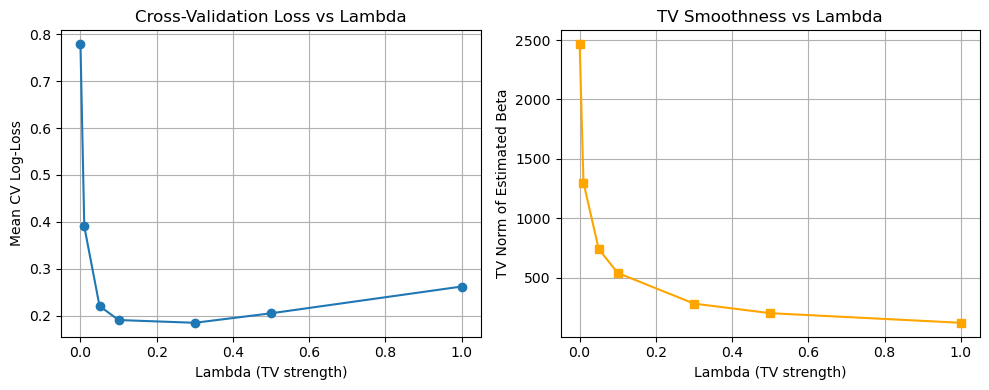

In [21]:
file_path = "Data/bootstrapped_analysis_ready.csv"
df = pd.read_csv(file_path)

mask = df["period"] > 2
df.loc[mask, "x_bin"] = 20 - 1 - df.loc[mask, "x_bin"]
df.loc[mask, "y_bin"] = 10 - 1 - df.loc[mask, "y_bin"]

df['x_bin'] = np.clip(df['x_bin'], 0, 20 - 1)
df['y_bin'] = np.clip(df['y_bin'], 0, 10 - 1)

# Grid configuration
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Map (x_bin, y_bin) to flat index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Prepare design matrix X and outcome vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)

possession_to_index = {p: i for i, p in enumerate(possessions)}
for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1

# Normalize each row of X to reduce bias from long possessions

# Lambda values to try
lambda_values = np.array([0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0])
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

lambda_log_losses = []
lambda_tv_magnitudes = []
beta_maps = []

for lambda_tv in tqdm.tqdm(lambda_values):
    fold_losses = []
    fold_tv_norms = []

    for train_idx, val_idx in kfold.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        beta_grid = cp.Variable((grid_width, grid_height))
        beta_flat = cp.vec(beta_grid, order="C")
        logits = X_train @ beta_flat
        log_likelihood = cp.sum(cp.multiply(y_train, logits) - cp.logistic(logits))

        # Total variation penalty
        tv_terms = []
        for x in range(grid_width):
            for y_idx in range(grid_height):
                if x + 1 < grid_width:
                    tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x + 1, y_idx]))
                if y_idx + 1 < grid_height:
                    tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x, y_idx + 1]))
        tv_penalty = cp.sum(tv_terms)

        constraints = [beta_grid >= -10, beta_grid <= 10]
        objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(solver=cp.ECOS,verbose=False)
            beta_est = beta_grid.value
        except:
            fold_losses.append(np.inf)
            fold_tv_norms.append(np.inf)
            continue

        if beta_est is not None:
            preds = 1 / (1 + np.exp(-(X_val @ beta_est.ravel(order="C"))))
            fold_losses.append(log_loss(y_val, preds))
            # Record TV norm
            tv_value = sum(
                np.abs(beta_est[x, y] - beta_est[x+1, y])
                for x in range(grid_width-1)
                for y in range(grid_height)
            ) + sum(
                np.abs(beta_est[x, y] - beta_est[x, y+1])
                for x in range(grid_width)
                for y in range(grid_height-1)
            )
            fold_tv_norms.append(tv_value)
        else:
            fold_losses.append(np.inf)
            fold_tv_norms.append(np.inf)

    lambda_log_losses.append(np.mean(fold_losses))
    lambda_tv_magnitudes.append(np.mean(fold_tv_norms))
    beta_maps.append(beta_est)

# Plot CV log-loss vs lambda
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(lambda_values, lambda_log_losses, marker='o')
plt.xlabel("Lambda (TV strength)")
plt.ylabel("Mean CV Log-Loss")
plt.title("Cross-Validation Loss vs Lambda")
plt.grid(True)

# Plot TV norm vs lambda
plt.subplot(1, 2, 2)
plt.plot(lambda_values, lambda_tv_magnitudes, marker='s', color='orange')
plt.xlabel("Lambda (TV strength)")
plt.ylabel("TV Norm of Estimated Beta")
plt.title("TV Smoothness vs Lambda")
plt.grid(True)
plt.tight_layout()
plt.show()

100%|██████████| 15/15 [01:02<00:00,  4.16s/it]


Best λ = 0.1389


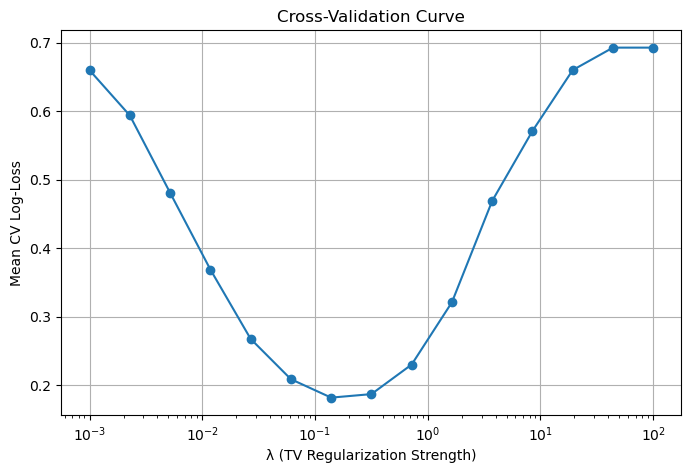

In [22]:
lambda_values = np.logspace(-3, 2, 15)  #(adjust as needed)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
y = np.array([group['scored'].iloc[0] for _, group in df_bootstrap.groupby('possession_number')], dtype=np.int8)

# Store mean validation loss per lambda
lambda_log_losses = []

for lambda_tv in tqdm.tqdm(lambda_values):
    fold_losses = []

    for train_idx, val_idx in kfold.split(X):
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_val = X[val_idx]
        y_val = y[val_idx]

        # Redefine variable and problem per fold
        beta_grid = cp.Variable((grid_width, grid_height))
        beta_flat = cp.vec(beta_grid, order="C")
        logits = X_train @ beta_flat
        log_likelihood = cp.sum(cp.multiply(y_train, logits) - cp.logistic(logits))

        # TV penalty
        tv_terms = []
        for x in range(grid_width):
            for y_ in range(grid_height):
                if x + 1 < grid_width:
                    tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x + 1, y_]))
                if y_ + 1 < grid_height:
                    tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x, y_ + 1]))
        tv_penalty = cp.sum(tv_terms)

        constraints = [beta_grid >= -10, beta_grid <= 10]
        objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
        problem = cp.Problem(objective, constraints)

        try:
            problem.solve(solver=cp.ECOS,verbose=False)
            beta_est = beta_grid.value
        except:
            fold_losses.append(np.inf)
            continue

        # Evaluate log-loss on validation set
        if beta_est is not None:
            preds = 1 / (1 + np.exp(-(X_val @ beta_est.ravel())))
            fold_losses.append(log_loss(y_val, preds))
        else:
            fold_losses.append(np.inf)

    # Average fold loss for this λ
    lambda_log_losses.append(np.mean(fold_losses))

# Select best λ
best_lambda = lambda_values[np.argmin(lambda_log_losses)]
print(f"Best λ = {best_lambda:.4f}")

plt.figure(figsize=(8, 5))
plt.semilogx(lambda_values, lambda_log_losses, marker='o')
plt.xlabel("λ (TV Regularization Strength)")
plt.ylabel("Mean CV Log-Loss")
plt.title("Cross-Validation Curve")
plt.grid(True)
plt.show()

(CVXPY) Jul 24 03:16:52 PM: Your problem has 200 variables, 400 constraints, and 0 parameters.
(CVXPY) Jul 24 03:16:52 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jul 24 03:16:52 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jul 24 03:16:52 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jul 24 03:16:52 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jul 24 03:16:52 PM: Compiling problem (target solver=ECOS).
(CVXPY) Jul 24 03:16:52 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Jul 24 03:16:52 PM: Applying reduction FlipObjective
(CVXPY) Jul 24 03:16:52 PM: Applying reduction Dcp2Cone
(CVXPY) Jul 24 03:16:53 PM: Applying reduction CvxAttr2Constr
(CVXPY) Jul 24 03:16:53 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.6.6                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jul 24 03:16:53 PM: Applying reduction ECOS
(CVXPY) Jul 24 03:16:53 PM: Finished problem compilation (took 5.406e-01 seconds).
(CVXPY) Jul 24 03:16:53 PM: Invoking solver ECOS  to obtain a solution.
(CVXPY) Jul 24 03:16:53 PM: Problem status: optimal
(CVXPY) Jul 24 03:16:53 PM: Optimal value: -1.246e+02
(CVXPY) Jul 24 03:16:53 PM: Compilation took 5.406e-01 seconds
(CVXPY) Jul 24 03:16:53 PM: Solver (including time spent in interface) took 1.315e-01 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


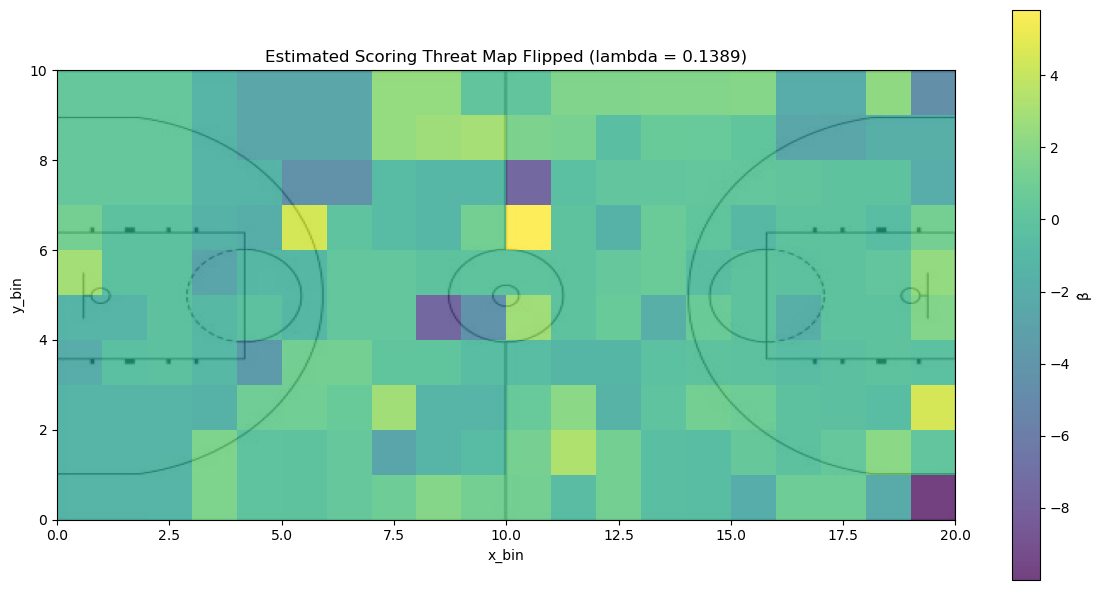

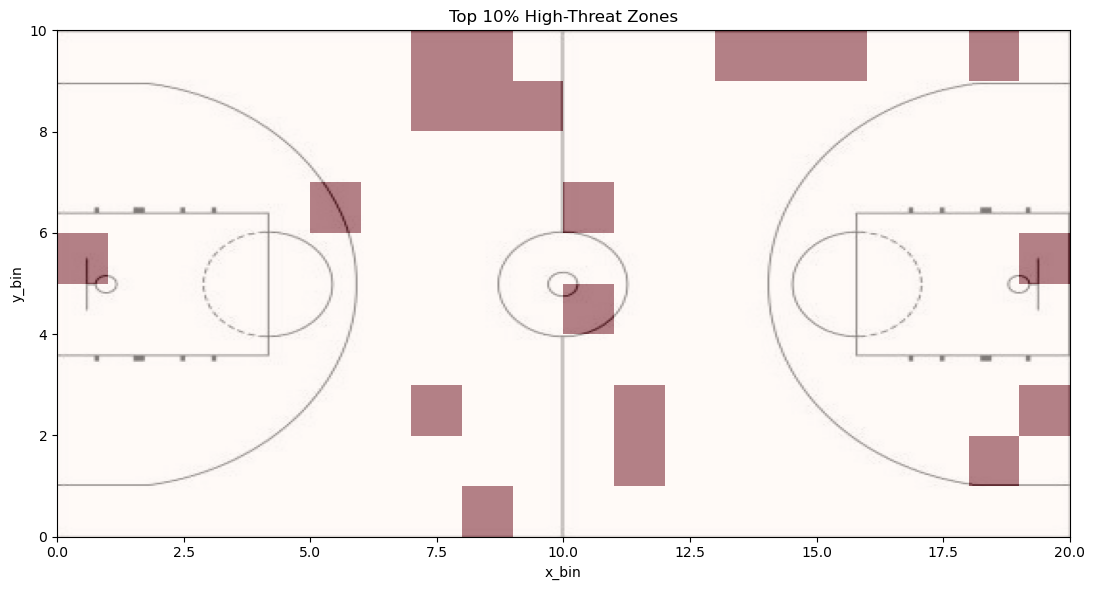

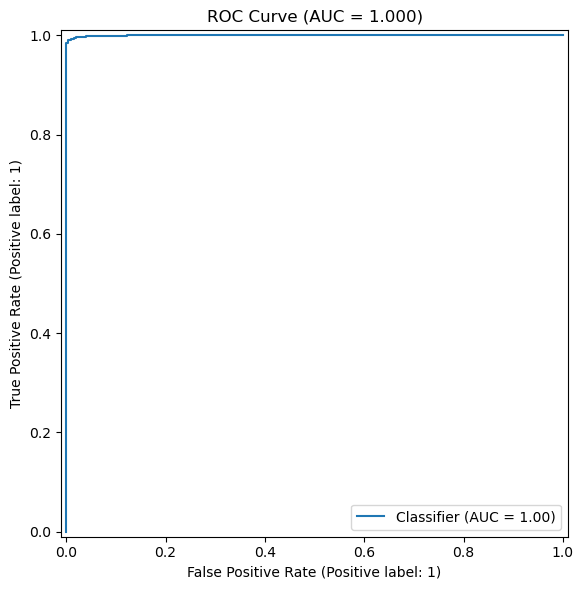

In [23]:
file_path = "Data/bootstrapped_analysis_ready.csv"
df = pd.read_csv(file_path)

# flipping bins
mask = df["period"] > 2
df.loc[mask, "x_bin"] = 20 - 1 - df.loc[mask, "x_bin"]
df.loc[mask, "y_bin"] = 10 - 1 - df.loc[mask, "y_bin"]

df['x_bin'] = np.clip(df['x_bin'], 0, 20 - 1)
df['y_bin'] = np.clip(df['y_bin'], 0, 10 - 1)

# Grid configuration
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Construct design matrix X and label vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)

possession_to_index = {p: i for i, p in enumerate(possessions)}
for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1

#X = normalize(X, norm='l1', axis=1)

# Fit final model with lambda = anything (lower seems to be better)
lambda_tv = 0.1389
beta_grid = cp.Variable((grid_width, grid_height))
beta_flat = cp.vec(beta_grid, order="C")
logits = X @ beta_flat
log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

# TV penalty
tv_terms = []
for x in range(grid_width):
    for y_idx in range(grid_height):
        if x + 1 < grid_width:
            tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x + 1, y_idx]))
        if y_idx + 1 < grid_height:
            tv_terms.append(cp.abs(beta_grid[x, y_idx] - beta_grid[x, y_idx + 1]))
tv_penalty = cp.sum(tv_terms)

constraints = [beta_grid >= -10, beta_grid <= 10]
objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.ECOS,verbose=True)

beta_est = beta_grid.value

# Plot heatmap on court image
court_img = mpimg.imread("court.jpg")
fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')
heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height], cmap="viridis", alpha=0.75)
ax.set_title(f"Estimated Scoring Threat Map Flipped (lambda = {lambda_tv})")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.colorbar(heatmap, ax=ax, label="β̂")
plt.tight_layout()
plt.show()

# Highlight high-threat zones
threshold = np.percentile(beta_est, 90)
mask = beta_est >= threshold

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')
ax.imshow(mask.T, origin="lower", extent=[0, grid_width, 0, grid_height], cmap="Reds", alpha=0.5)
ax.set_title("Top 10% High-Threat Zones")
ax.set_xlabel("x_bin")
ax.set_ylabel("y_bin")
plt.tight_layout()
plt.show()

mu_hat = 1 / (1 + np.exp(-(X @ beta_est.ravel(order="C"))))
auc_score = roc_auc_score(y, mu_hat)

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y, mu_hat, ax=ax)
ax.set_title(f"ROC Curve (AUC = {auc_score:.3f})")
plt.tight_layout()
plt.show()

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for train_idx, val_idx in kfold.split(X):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Define and solve TV-penalized logistic regression
    beta_grid = cp.Variable((grid_width, grid_height))
    beta_flat = cp.vec(beta_grid, order="C")
    logits = X_train @ beta_flat
    log_likelihood = cp.sum(cp.multiply(y_train, logits) - cp.logistic(logits))

    tv_terms = []
    for x in range(grid_width):
        for y_ in range(grid_height):
            if x + 1 < grid_width:
                tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x + 1, y_]))
            if y_ + 1 < grid_height:
                tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x, y_ + 1]))
    tv_penalty = cp.sum(tv_terms)

    problem = cp.Problem(cp.Maximize(log_likelihood - lambda_tv * tv_penalty),
                         [beta_grid >= -10, beta_grid <= 10])
    problem.solve(verbose=False)

    if beta_grid.value is not None:
        mu_val = 1 / (1 + np.exp(-(X_val @ beta_grid.value.ravel(order="C"))))
        auc_scores.append(roc_auc_score(y_val, mu_val))

print(f"Mean CV AUC = {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# AUC maybe not necessary

In [ ]:
# Individual quarter analysis
# AIC, BIC, QUT metrics
# AUC a little naive due to data leakage potential
# Quantile Universal Threshold (QUT) can be used to derive lambda using the null hypothesis where the threat across the map is constant
# Perform other types of smoothing other than TV (splines, SVC)

## Per Quarter Analysis using Bootstrapped Data

In [ ]:
# Load data
file_path = "Data/bootstrapped_analysis_ready.csv"
df = pd.read_csv(file_path)

# Flip bins for second half
mask = df["period"] > 2
df.loc[mask, "x_bin"] = 20 - 1 - df.loc[mask, "x_bin"]
df.loc[mask, "y_bin"] = 10 - 1 - df.loc[mask, "y_bin"]
df['x_bin'] = np.clip(df['x_bin'], 0, 19)
df['y_bin'] = np.clip(df['y_bin'], 0, 9)

# Grid parameters
grid_width, grid_height = 20, 10
num_bins = grid_width * grid_height
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}
court_img = mpimg.imread("court.jpg")
lambda_tv = 0.1389  # adjust as needed

# Loop through each period
for period in sorted(df['period'].unique()):
    df_period = df[df['period'] == period]

    # Build design matrix X and response y
    possessions = df_period['possession_number'].unique()
    n_possessions = len(possessions)
    X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
    y = np.array([group['scored'].iloc[0] for _, group in df_period.groupby('possession_number')], dtype=np.int8)
    possession_to_index = {p: i for i, p in enumerate(possessions)}

    for pid, group in df_period.groupby('possession_number'):
        i = possession_to_index[pid]
        visited_bins = set(zip(group['x_bin'], group['y_bin']))
        for xb, yb in visited_bins:
            if (xb, yb) in bin_to_index:
                X[i, bin_to_index[(xb, yb)]] = 1

    # Define optimization problem
    beta_grid = cp.Variable((grid_width, grid_height))
    beta_flat = cp.vec(beta_grid, order="C")
    logits = X @ beta_flat
    log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

    tv_terms = []
    for x in range(grid_width):
        for y_ in range(grid_height):
            if x + 1 < grid_width:
                tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x + 1, y_]))
            if y_ + 1 < grid_height:
                tv_terms.append(cp.abs(beta_grid[x, y_] - beta_grid[x, y_ + 1]))
    tv_penalty = cp.sum(tv_terms)

    constraints = [beta_grid >= -10, beta_grid <= 10]
    objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
    problem = cp.Problem(objective, constraints)

    try:
        result = problem.solve(solver=cp.ECOS, verbose=True)
        beta_est = beta_grid.value
    except:
        print(f"Optimization failed for period {period}")
        continue

    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')
    heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height],
                        cmap="viridis", alpha=0.75)
    ax.set_title(f"Scoring Threat Map (Period {period})")
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    plt.colorbar(heatmap, ax=ax, label="β̂")
    plt.tight_layout()
    plt.show()

    # Highlight top 10% zones
    threshold = np.percentile(beta_est, 90)
    mask = beta_est >= threshold
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')
    ax.imshow(mask.T, origin="lower", extent=[0, grid_width, 0, grid_height],
              cmap="Reds", alpha=0.5)
    ax.set_title(f"Top 10% High-Threat Zones (Period {period})")
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    plt.tight_layout()
    plt.show()


## Quantile Universal Threshold

### Constructing X

Same method as before.

In [ ]:
df = pd.read_csv("Data/analysis_ready.csv")

# Dimensions of your bin grid
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Step 1: Map each (x_bin, y_bin) to index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Step 2: Prepare possession-level feature matrix X and outcome vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)
possession_to_index = {p: i for i, p in enumerate(possessions)}

for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1
    y[i] = group['scored'].iloc[0]

### Constructing D_TV, the Total Variation Matrix

Used to represent the total variation between corresponding edges. Each bin is assigned a -1 and it's neighbors are assigned a 1 as a baseline value.

In [ ]:
rows = []
for xx in range(grid_width - 1):
    for yy in range(grid_height):
        i = xx * grid_height + yy
        row = np.zeros(num_bins)
        row[i] = -1
        row[i + grid_height] = 1
        rows.append(row)

for xx in range(grid_width):
    for yy in range(grid_height - 1):
        i = xx * grid_height + yy
        row = np.zeros(num_bins)
        row[i] = -1
        row[i + 1] = 1
        rows.append(row)

D_TV = np.vstack(rows)
print(D_TV.shape)
print(X.shape)

In [ ]:
def solve_infinity_norm(y, X, D, project_grad_h=False):
    m = D.shape[0]

    # Step 1: Fit logistic regression with constant input
    try:
        X0 = X @ np.ones((X.shape[1], 1))
        clf = LogisticRegression(fit_intercept=False, solver='lbfgs')
        clf.fit(X0, y)
        beta0 = clf.coef_.flatten()
    except Exception as e:
        raise ValueError(f"Logistic regression failed: {e}")

    # Step 2: Compute predicted probabilities
    u0 = beta0[0] * np.ones(X.shape[1])
    p = 1 / (1 + np.exp(-X @ u0))
    p = np.clip(p, 1e-6, 1 - 1e-6)

    if np.any(np.isnan(p)) or np.any(np.isinf(p)):
        raise ValueError("Invalid probabilities p (NaN or Inf)")

    # Step 3: Compute gradient
    grad_h = X.T @ (y - p)

    if np.any(np.isnan(grad_h)) or np.any(np.isinf(grad_h)):
        raise ValueError("Invalid grad_h (NaN or Inf)")

    # Optional: project grad_h to column space of Dᵗ
    if project_grad_h:
        try:
            P = D.T @ pinv(D @ D.T) @ D
            grad_h = grad_h.reshape(-1, 1)
            grad_h = (P @ grad_h).flatten()

        except Exception as e:
            raise ValueError(f"Projection failed: {e}")

    # Step 4: Solve the constrained optimization
    w = cp.Variable(m)
    constraints = [D.T @ w == grad_h]
    objective = cp.Minimize(cp.norm(w, "inf"))
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS, verbose=False)

    # Step 5: Check solver status
    if prob.status != "optimal":
        raise ValueError(f"Optimization failed. Status: {prob.status}")

    return w.value, prob.value

def lambda_qut(X, y, D_TV, MC=100):
    X0 = X @ np.ones((X.shape[1], 1))
    clf = LogisticRegression(fit_intercept=False, solver='lbfgs')
    clf.fit(X0, y)
    x0 = clf.coef_.flatten()
    mu0 = X0 @ x0
    p0 = 1 / (1 + np.exp(-mu0))
    p0 = np.clip(p0, 1e-6, 1 - 1e-6)

    Lambdas = []
    attempts = 0

    print("Simulating null responses...")
    while len(Lambdas) < MC and attempts < MC * 20:
        attempts += 1
        y_sim = binom.rvs(1, p0)

        if np.all(y_sim == 0) or np.all(y_sim == 1):
            print(f"Skipping degenerate simulation (all {int(y_sim[0])})")
            continue

        try:
            _, lambda_val = solve_infinity_norm(y_sim, X, D_TV, project_grad_h=True)
            if np.isfinite(lambda_val):
                Lambdas.append(lambda_val)
                if len(Lambdas) % 100 == 0:
                    print(f"Accepted {len(Lambdas)} / {MC} simulations")
            else:
                print("Skipping non-finite lambda")
        except Exception as e:
            print(f"Skipping simulation due to error: {e}")

    if len(Lambdas) == 0:
        raise RuntimeError("All simulations failed. Check your data or D matrix.")

    lambda_qut_val = np.quantile(Lambdas, 0.95)

    try:
        _, lambda_max = solve_infinity_norm(y, X, D_TV, project_grad_h=True)
    except Exception as e:
        raise RuntimeError(f"Optimization on real data failed: {e}")

    print(f"λ_qut (95th percentile null): {lambda_qut_val:.4f}")
    print(f"λ_max (data): {lambda_max:.4f}")
    return lambda_qut_val, lambda_max, Lambdas


In [ ]:
lambda_qut_val, lambda_max, lambdas_null = lambda_qut(X, y, D_TV, MC=1000)

### Unidirectional

In [ ]:
df_flipped = df.copy()

mask = df["period"] > 2
df_flipped.loc[mask, "x_bin"] = 20 - 1 - df_flipped.loc[mask, "x_bin"]
df_flipped.loc[mask, "y_bin"] = 10 - 1 - df_flipped.loc[mask, "y_bin"]
df_flipped['x_bin'] = np.clip(df_flipped['x_bin'], 0, 19)
df_flipped['y_bin'] = np.clip(df_flipped['y_bin'], 0, 9)

In [ ]:
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Step 1: Map each (x_bin, y_bin) to index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Step 2: Prepare possession-level feature matrix X and outcome vector y
possessions = df_flipped['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df_flipped.groupby('possession_number')], dtype=np.int8)
possession_to_index = {p: i for i, p in enumerate(possessions)}

for pid, group in df_flipped.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1
    y[i] = group['scored'].iloc[0]

rows = []
for xx in range(grid_width - 1):
    for yy in range(grid_height):
        i = xx * grid_height + yy
        row = np.zeros(num_bins)
        row[i] = -1
        row[i + grid_height] = 1
        rows.append(row)

for xx in range(grid_width):
    for yy in range(grid_height - 1):
        i = xx * grid_height + yy
        row = np.zeros(num_bins)
        row[i] = -1
        row[i + 1] = 1
        rows.append(row)

D_TV = np.vstack(rows)

In [ ]:
lambda_qut_val, lambda_max, lambdas_null = lambda_qut(X, y, D_TV, MC=1000)

In [ ]:
df_flipped.describe()

## Using Calculated QUTs for Visualization

Should be fairly constant with values close to zero.

In [ ]:
def tv_logistic_regression_heatmap(df, lambda_tv=1.0, grid_width=20, grid_height=10, court_image_path="court.jpg"):
    num_bins = grid_width * grid_height

    # Map (x_bin, y_bin) to linear index
    bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

    # Unique possessions
    possessions = df['possession_number'].unique()
    n_possessions = len(possessions)
    X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
    y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)
    possession_to_index = {p: i for i, p in enumerate(possessions)}

    for pid, group in df.groupby('possession_number'):
        i = possession_to_index[pid]
        visited_bins = set(zip(group['x_bin'], group['y_bin']))
        for xb, yb in visited_bins:
            if (xb, yb) in bin_to_index:
                X[i, bin_to_index[(xb, yb)]] = 1
        y[i] = group['scored'].iloc[0]

    # Define CVXPY variables
    beta_grid = cp.Variable((grid_width, grid_height))
    beta_flat = cp.vec(beta_grid, order="C")
    logits = X @ beta_flat
    log_likelihood = cp.sum(cp.multiply(y, logits) - cp.logistic(logits))

    # TV penalty terms
    tv_terms = []
    for x in range(grid_width):
        for y in range(grid_height):
            if x + 1 < grid_width:
                tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x + 1, y]))
            if y + 1 < grid_height:
                tv_terms.append(cp.abs(beta_grid[x, y] - beta_grid[x, y + 1]))

    # Regularized objective
    constraints = [beta_grid >= -10, beta_grid <= 10]
    tv_penalty = cp.sum(tv_terms)
    objective = cp.Maximize(log_likelihood - lambda_tv * tv_penalty)
    problem = cp.Problem(objective, constraints)

    # Solve the optimization problem
    try:
        result = problem.solve(solver=cp.ECOS, verbose=True)
    except:
        print("ECOS failed, trying SCS...")
        result = problem.solve(solver=cp.SCS, verbose=False)

    if beta_grid.value is None:
        raise RuntimeError("Optimization failed. Check data integrity or constraints.")

    beta_est = beta_grid.value

    # Visualization
    court_img = mpimg.imread(court_image_path)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect='auto')

    heatmap = ax.imshow(beta_est.T, origin="lower", extent=[0, grid_width, 0, grid_height],
                        cmap="viridis", alpha=0.75)

    ax.set_title("Estimated Scoring Threat Map")
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    plt.colorbar(heatmap, ax=ax, label="β̂ value")
    plt.tight_layout()
    plt.show()

In [ ]:
tv_logistic_regression_heatmap(df, lambda_tv=.85)

In [ ]:
def bootstrap_lambda_max(X, y, D_TV, B=100, project_grad_h=True, seed=None):
    if seed is not None:
        np.random.seed(seed)

    n = len(y)
    lambda_max_bootstrap = []

    for _ in range(B):
        idx = np.random.choice(n, size=n, replace=True)
        X_b = X[idx]
        y_b = y[idx]

        try:
            _, lambda_b = solve_infinity_norm(y_b, X_b, D_TV, project_grad_h=project_grad_h)
            if np.isfinite(lambda_b):
                lambda_max_bootstrap.append(lambda_b)
        except:
            continue

    return np.array(lambda_max_bootstrap)

In [ ]:
df = pd.read_csv("Data/analysis_ready.csv")

# Dimensions of your bin grid
grid_width = 20
grid_height = 10
num_bins = grid_width * grid_height

# Step 1: Map each (x_bin, y_bin) to index
bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

# Step 2: Prepare possession-level feature matrix X and outcome vector y
possessions = df['possession_number'].unique()
n_possessions = len(possessions)
X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)
possession_to_index = {p: i for i, p in enumerate(possessions)}

for pid, group in df.groupby('possession_number'):
    i = possession_to_index[pid]
    visited_bins = set(zip(group['x_bin'], group['y_bin']))
    for xb, yb in visited_bins:
        if (xb, yb) in bin_to_index:
            X[i, bin_to_index[(xb, yb)]] = 1
    y[i] = group['scored'].iloc[0]

rows = []
for xx in range(grid_width - 1):
    for yy in range(grid_height):
        i = xx * grid_height + yy
        row = np.zeros(num_bins)
        row[i] = -1
        row[i + grid_height] = 1
        rows.append(row)

for xx in range(grid_width):
    for yy in range(grid_height - 1):
        i = xx * grid_height + yy
        row = np.zeros(num_bins)
        row[i] = -1
        row[i + 1] = 1
        rows.append(row)

D_TV = np.vstack(rows)

lambda_qut_val, lambda_max, lambdas_null = lambda_qut(X, y, D_TV, MC=1000)

In [ ]:
lambda_max_samples = bootstrap_lambda_max(X, y, D_TV, B=1000)
ci_lower, ci_upper = np.quantile(lambda_max_samples, [0.025, 0.975])
p_val = np.mean(np.array(lambdas_null) >= lambda_max)
print(f"95% CI for λ_max: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Empirical p-value for λ_max > λ_qut: {p_val:.4f}")

In [ ]:
plt.figure(figsize=(10, 6))

# Null distribution
plt.hist(lambdas_null, bins=30, alpha=0.6, label="Null distribution (λ)", color='skyblue', density=True)

# Bootstrap distribution of λ_max (observed)
plt.hist(lambda_max_samples, bins=30, alpha=0.6, label="Bootstrap λ_max (observed)", color='salmon', density=True)

# λ_max (observed)
plt.axvline(lambda_max, color='red', label='λ_max (observed)', linewidth=2)

# λ_QUT (95th percentile of null)
plt.axvline(np.quantile(lambdas_null, 0.95), color='black', linestyle='--', label='λ_QUT (95th null)')

# Bootstrap CI bounds
plt.axvline(ci_lower, color='blue', linestyle=':', label='λ_max 95% CI (lower)')
plt.axvline(ci_upper, color='blue', linestyle=':', label='λ_max 95% CI (upper)')

# Labels
plt.legend()
plt.xlabel("λ value")
plt.ylabel("Density")
plt.title("Overlay of λ_max Distributions: Null vs. Observed")

plt.show()

In [ ]:
# Dimensions of your bin grid
def grid(df):
    grid_width = 20
    grid_height = 10
    num_bins = grid_width * grid_height
    
    # Step 1: Map each (x_bin, y_bin) to index
    bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}
    
    # Step 2: Prepare possession-level feature matrix X and outcome vector y
    possessions = df['possession_number'].unique()
    n_possessions = len(possessions)
    X = lil_matrix((n_possessions, num_bins), dtype=np.float32)
    y = np.array([group['scored'].iloc[0] for _, group in df.groupby('possession_number')], dtype=np.int8)
    possession_to_index = {p: i for i, p in enumerate(possessions)}
    
    for pid, group in df.groupby('possession_number'):
        i = possession_to_index[pid]
        visited_bins = set(zip(group['x_bin'], group['y_bin']))
        for xb, yb in visited_bins:
            if (xb, yb) in bin_to_index:
                X[i, bin_to_index[(xb, yb)]] = 1
        y[i] = group['scored'].iloc[0]
    
    rows = []
    for xx in range(grid_width - 1):
        for yy in range(grid_height):
            i = xx * grid_height + yy
            row = np.zeros(num_bins)
            row[i] = -1
            row[i + grid_height] = 1
            rows.append(row)
    
    for xx in range(grid_width):
        for yy in range(grid_height - 1):
            i = xx * grid_height + yy
            row = np.zeros(num_bins)
            row[i] = -1
            row[i + 1] = 1
            rows.append(row)
    D_TV = np.vstack(rows)
    return X, y, D_TV

In [ ]:
for period in df["period"].unique():
    print(f"Period {period}")

    df_period = df[df["period"] == period]
    X, y, D_TV = grid(df_period)

    lambda_max_samples = bootstrap_lambda_max(X, y, D_TV, B=1000)
    lambda_max = np.median(lambda_max_samples)

    lambda_qut_val, lambda_max_true, lambdas_null = lambda_qut(X, y, D_TV, MC=1000)

    ci_lower, ci_upper = np.quantile(lambda_max_samples, [0.025, 0.975])
    p_val = np.mean(np.array(lambdas_null) >= lambda_max)

    print(f"95% CI for λ_max in period {period}: [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Empirical p-value for λ_max > λ_qut in period {period}: {p_val:.4f}\n")